In [4]:
#Ejercicio 1

x1, x2 = 2, 3
w1, w2 = 0.5, -1
bias = 1

# 1. Calcular la suma ponderada
z = x1 * w1 + x2 * w2 + bias

# 2. Aplica la activación Relu
def relu(z):
    return max(0, z)

y = relu(z)

# 3. Aplica la activación Sigmoid
import math

def sigmoid(z):
    return 1 / (1 + math.exp(-z))

y = sigmoid(z)

# 4. Compara los resultados de las activaciones
print("Resultado de la activación ReLU:", relu(z))
print("Resultado de la activación Sigmoid:", sigmoid(z))

#¿Por qué los resultados son diferentes?
print("La activación ReLU devuelve 0 para valores negativos, mientras que la activación Sigmoid devuelve un valor entre 0 y 1.")

Resultado de la activación ReLU: 0
Resultado de la activación Sigmoid: 0.2689414213699951
La activación ReLU devuelve 0 para valores negativos, mientras que la activación Sigmoid devuelve un valor entre 0 y 1.


In [2]:
#Ejercicio 2
from tensorflow import keras
from tensorflow.keras import layers

# Construir una red sencilla para clasificar flores, usando el dataset Iris (4 características, 3 clases)
model = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(3, activation='softmax')
])

# 1. Ejecuta el modelo summary para ver la arquitectura de la red
model.summary()

# 2. Calcular el numero de parámetros de la primera capa
# La primera capa tiene 4 entradas y 16 neuronas, por lo que el número de parámetros es (4 * 16) + 16 = 80
num_params_first_layer = (4 * 16) + 16
print("Número de parámetros de la primera capa:", num_params_first_layer)

# 3. Calcular el numero de parámetros de la segunda capa
# La segunda capa tiene 16 entradas y 3 neuronas, por lo que el número de parámetros es (16 * 3) + 3 = 51
num_params_second_layer = (16 * 3) + 3
print("Número de parámetros de la segunda capa:", num_params_second_layer)

# 4. Comprueba que los cálculos son correctos comparando con el summary del modelo
# El summary del modelo muestra el número total de parámetros, que debe coincidir con la suma de los parámetros de ambas capas
total_params = num_params_first_layer + num_params_second_layer
print("Número total de parámetros:", total_params)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

Número de parámetros de la primera capa: 80
Número de parámetros de la segunda capa: 51
Número total de parámetros: 131


In [5]:
#Ejercicio 3
#Usa el modelo del ejercicio 2
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 1. Explica que hace cada parámetro del método compile
# - optimizer='adam': Este parámetro especifica el optimizador que se utilizará para actualizar los pesos de la red durante el entrenamiento. Adam es un optimizador que combina las ventajas de dos métodos de optimización: AdaGrad y RMSProp.
# - loss='sparse_categorical_crossentropy': Este parámetro especifica la función de pérdida que se utilizará para evaluar el rendimiento del modelo durante el entrenamiento. La pérdida de entropía cruzada categórica escasa es adecuada para problemas de clasificación multiclase donde las etiquetas son enteros.
# - metrics=['accuracy']: Este parámetro especifica las métricas que se utilizarán para evaluar el rendimiento del modelo durante el entrenamiento y la evaluación. En este caso, se está utilizando la precisión (accuracy) como métrica.

# 2. Sin ejecutar fit() todavia, ¿el modelo ya sabe clasificar flores? ¿Por qué?
# No, el modelo no sabe clasificar flores todavía. 
# Aunque la arquitectura del modelo está definida, los pesos de la red aún no han sido entrenados con datos. 
# El modelo necesita ser entrenado con un conjunto de datos de flores (como el dataset Iris) para aprender a clasificar correctamente

# 3. Investiga, ¿Por qué se usa la función de pérdida sparse_categorical_crossentropy y no mse para este caso?
# La función de pérdida sparse_categorical_crossentropy se utiliza en problemas de clasificación multiclase porque está diseñada para manejar
# etiquetas enteras que representan las clases. 
# En este caso, el dataset Iris tiene etiquetas enteras que representan las diferentes especies de flores.

In [6]:
#Ejercicio 4
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Cargar el dataset Iris
iris = load_iris()
X, y = iris.data, iris.target

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 1. Entrena el modelo de los ejercicios 2 y 3 con fit
model.fit(X_train, y_train, epochs=30, batch_size=8, validation_split=0.15)

# 2. Guarda el resultado del entrenamiento en una variable history
history = model.fit(X_train, y_train, epochs=30, batch_size=8, validation_split=0.15)

# 3. Evalua el modelo sobre X_test y y_test con evaluate y anota el accuracy obtenida
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# 4. Genera predicciones sobre las 3 primeras filas de X_test con predict y compara con las etiquetas reales de y_test
predictions = model.predict(X_test[:3])
print(f"Predictions: {predictions}")
print(f"Actual Labels: {y_test[:3]}")



Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3627 - loss: 1.3503 - val_accuracy: 0.1667 - val_loss: 1.4277
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3627 - loss: 1.1992 - val_accuracy: 0.2222 - val_loss: 1.2560
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3725 - loss: 1.1432 - val_accuracy: 0.2222 - val_loss: 1.1802
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3824 - loss: 1.0941 - val_accuracy: 0.2778 - val_loss: 1.1252
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3627 - loss: 1.0546 - val_accuracy: 0.1667 - val_loss: 1.1092
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3627 - loss: 1.0220 - val_accuracy: 0.2222 - val_loss: 1.0746
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3725 - loss: 0.9920 - val_accuracy: 0.1667 - val_loss: 1.0447
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4020 - loss: 0.9653 - val_accuracy: 0.2222 - val_loss

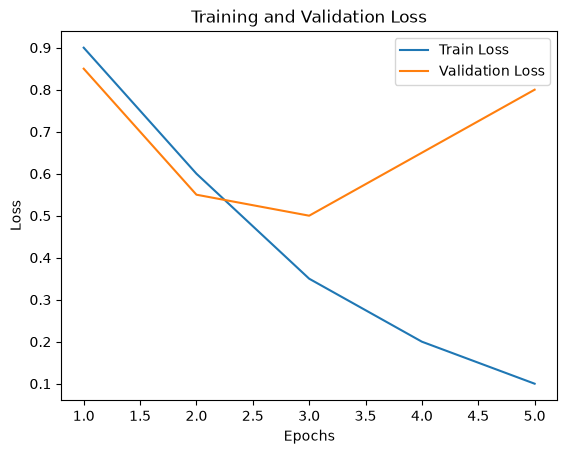

In [7]:
#Ejercicio 5

#Epoch:      1   2   3   4   5
#Train loss: 0.9 0.6 0.35 0.2 0.1
#Val loss:   0.85 0.55 0.5 0.65 0.8

# 1. Dibuja con plt.plot() las curvas de loss de entrenamiento y validación en función de las epochs.
import matplotlib.pyplot as plt

plt.plot([1, 2, 3, 4, 5], [0.9, 0.6, 0.35, 0.2, 0.1], label='Train Loss')
plt.plot([1, 2, 3, 4, 5], [0.85, 0.55, 0.5, 0.65, 0.8], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# 2. ¿En que epoch las curvas de loss de entrenamiento y validación se separan? ¿Qué significa esto?
# Las curvas de loss de entrenamiento y validación se separan a partir de la epoch 3. 
# Esto significa que el modelo comienza a sobreajustarse a los datos de entrenamiento, 
# lo que indica que está aprendiendo patrones específicos de los datos de entrenamiento que no generalizan bien a los datos de validación.

# 3. ¿Qué fenomeno está ocurriendo en el modelo? ¿Qué significa esto?
# El fenómeno que está ocurriendo es el sobreajuste (overfitting).

# 4. ¿Qué callback de Keras se puede usar para evitar este fenómeno? ¿Cómo se usa?
# Se puede usar el callback EarlyStopping de Keras para evitar el sobreajuste.

In [ ]:
#Ejercicio 6
#Sigue usando el modelo y los datos del ejercicio 4

from tensorflow.keras.callbacks import EarlyStopping

early_stop=EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 1. Vuelve a entrenar el modelo usando fit() pero esta vez usando el callback EarlyStopping.
history = model.fit(X_train, y_train, epochs=200, batch_size=8, validation_split=0.15, callbacks=[early_stop])

# 2. Comprueba cuantas epochs se entrenaron realmente con len(history.history['loss'])
print(len(history.history['loss']))

# 3. Compara ese número con las 200 epochs que pediste: ¿se detuvo antes? ¿Por qué podría no detenerse antes en un dataset sencillo como Iris?


In [ ]:
#Ejercicio 7

#Modelo A. Sin Dropout
modelo_a = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')
])

#Modelo B. Con Dropout
modelo_b = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
])

# 1. Compila y entrena ambos modelos con los mismos datos y mismos epochs (por ejemplo, 100)